JRDB_gold/jsons_gold/cubberly-auditorium-2019-04-22_1_00051.json
JRDB_gold/videos_frames/cubberly-auditorium-2019-04-22_1_00051/00001.jpeg
441
2427


/tmp/ipykernel_5536/3552957618.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap("tab20", 20)


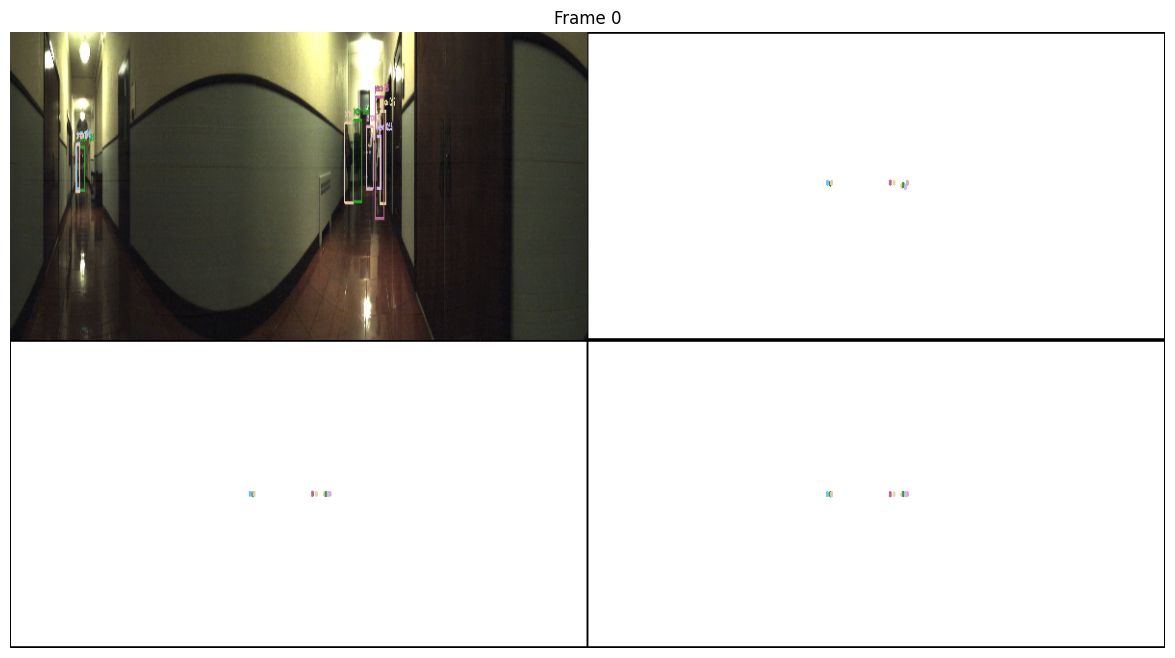

JRDB_gold/videos_frames/cubberly-auditorium-2019-04-22_1_00051/00002.jpeg
436
2423


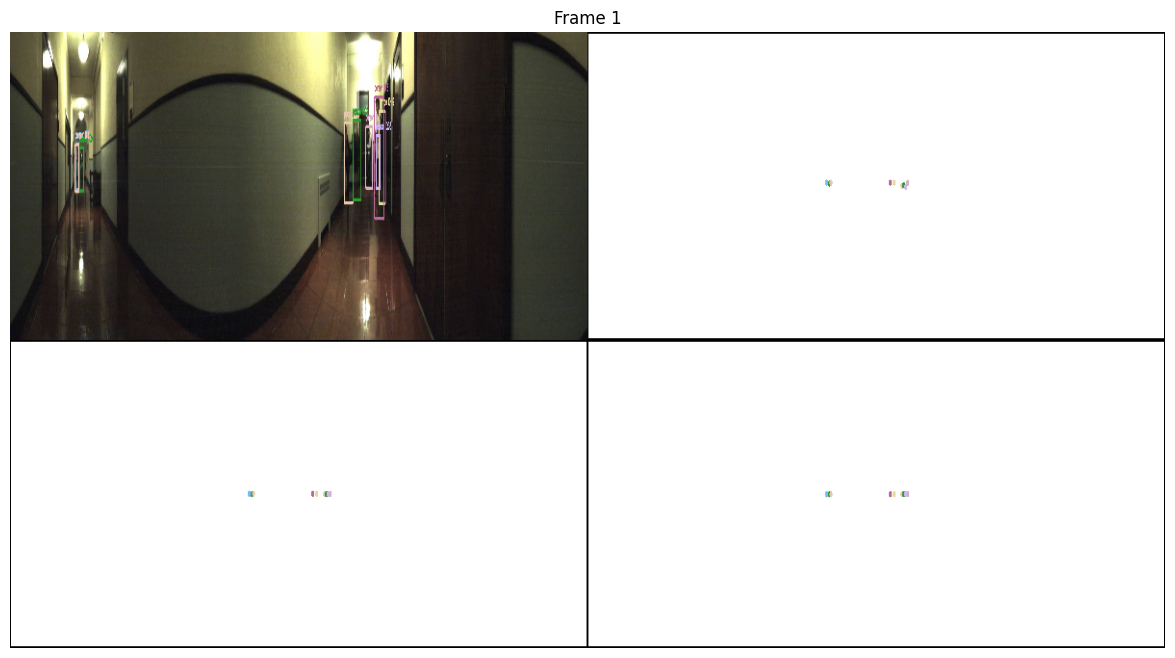

JRDB_gold/videos_frames/cubberly-auditorium-2019-04-22_1_00051/00003.jpeg
429
2421


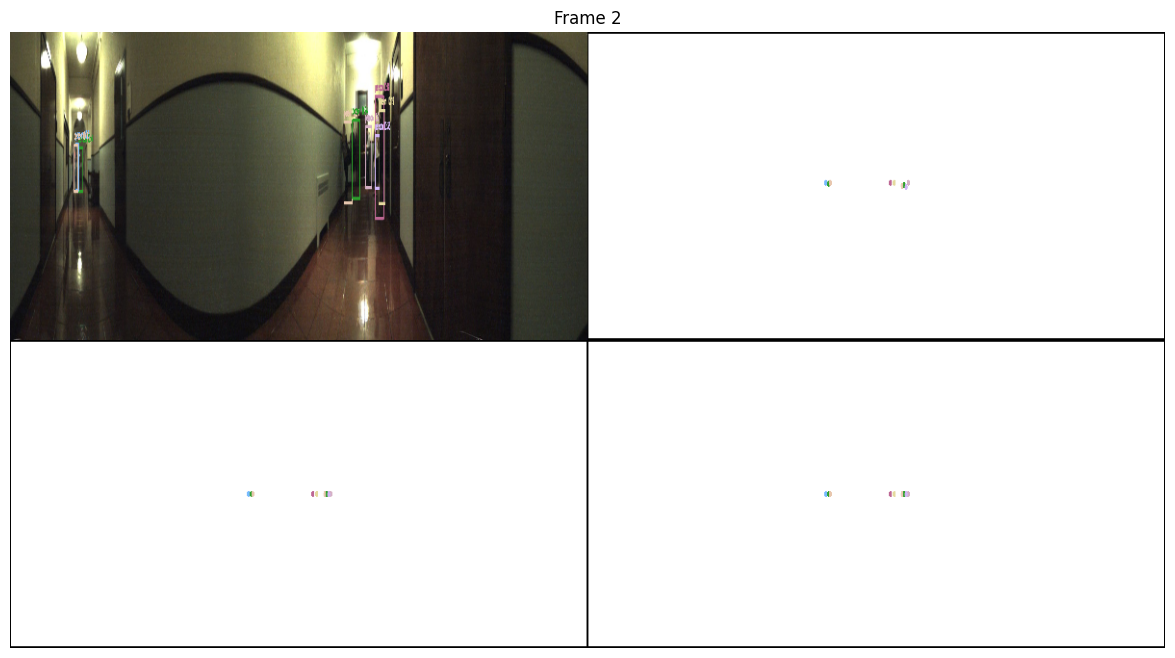

JRDB_gold/videos_frames/cubberly-auditorium-2019-04-22_1_00051/00004.jpeg
421
2414


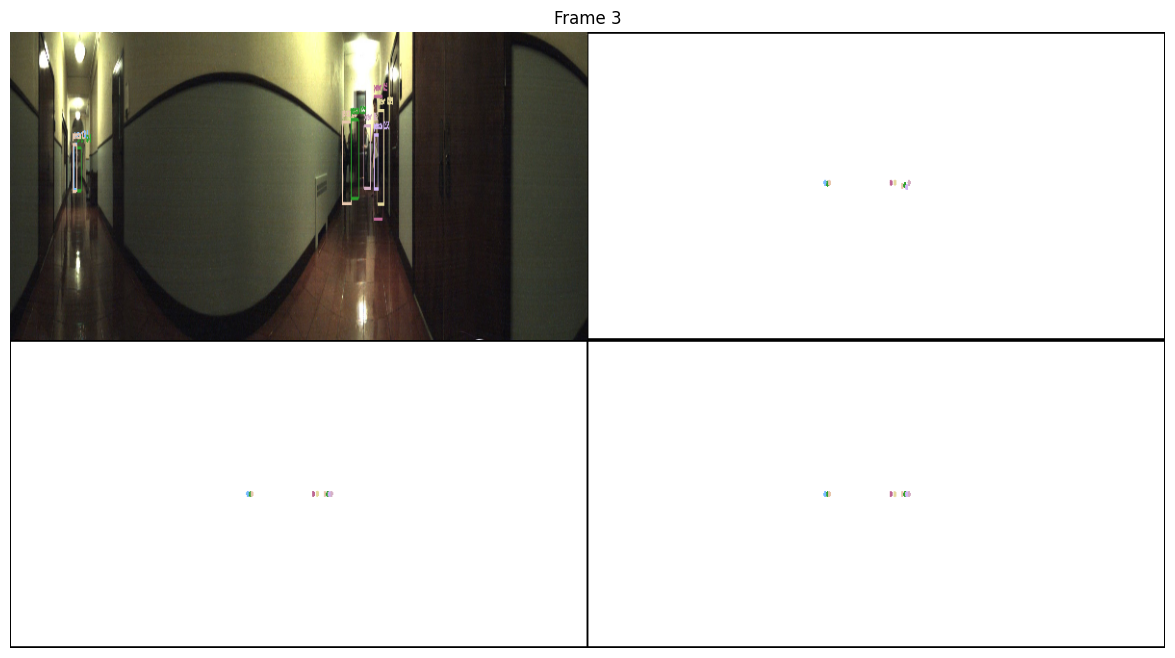

JRDB_gold/videos_frames/cubberly-auditorium-2019-04-22_1_00051/00005.jpeg
411
2405


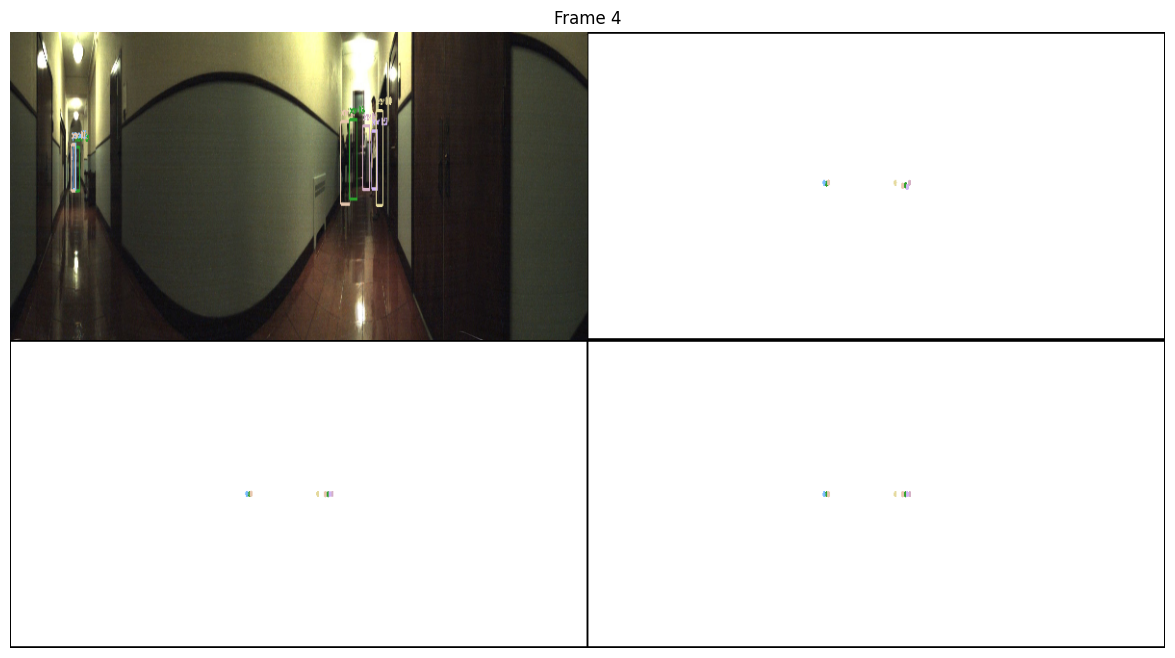

JRDB_gold/videos_frames/cubberly-auditorium-2019-04-22_1_00051/00006.jpeg
399
2397


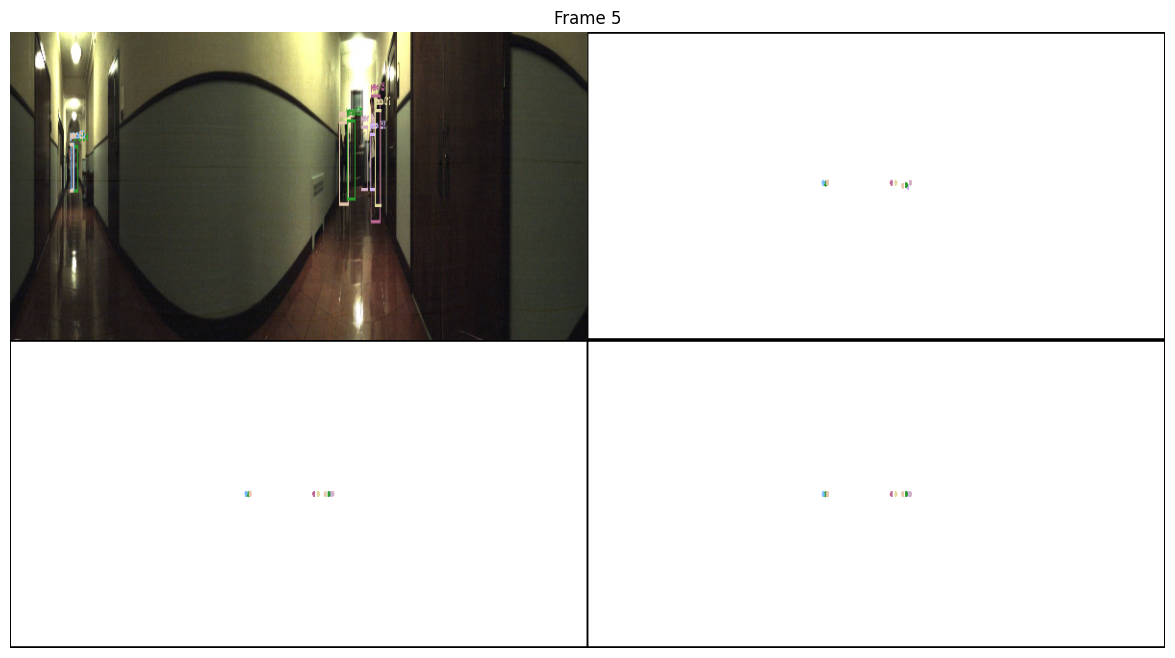

JRDB_gold/videos_frames/cubberly-auditorium-2019-04-22_1_00051/00007.jpeg
387
2389


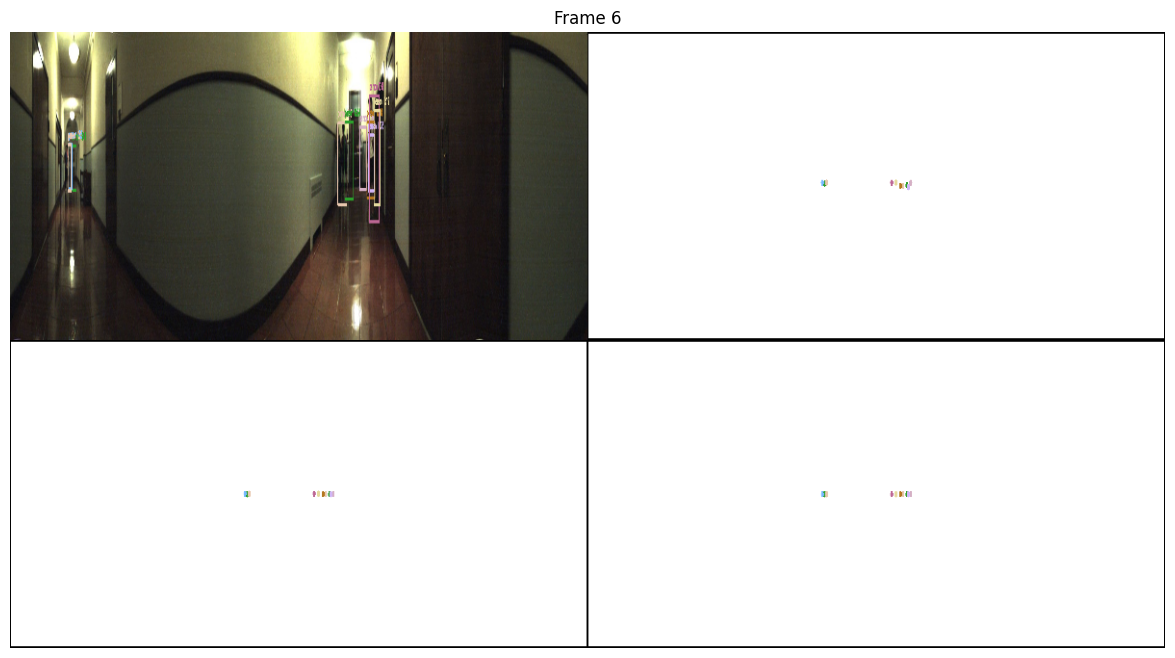

JRDB_gold/videos_frames/cubberly-auditorium-2019-04-22_1_00051/00008.jpeg
375
2377


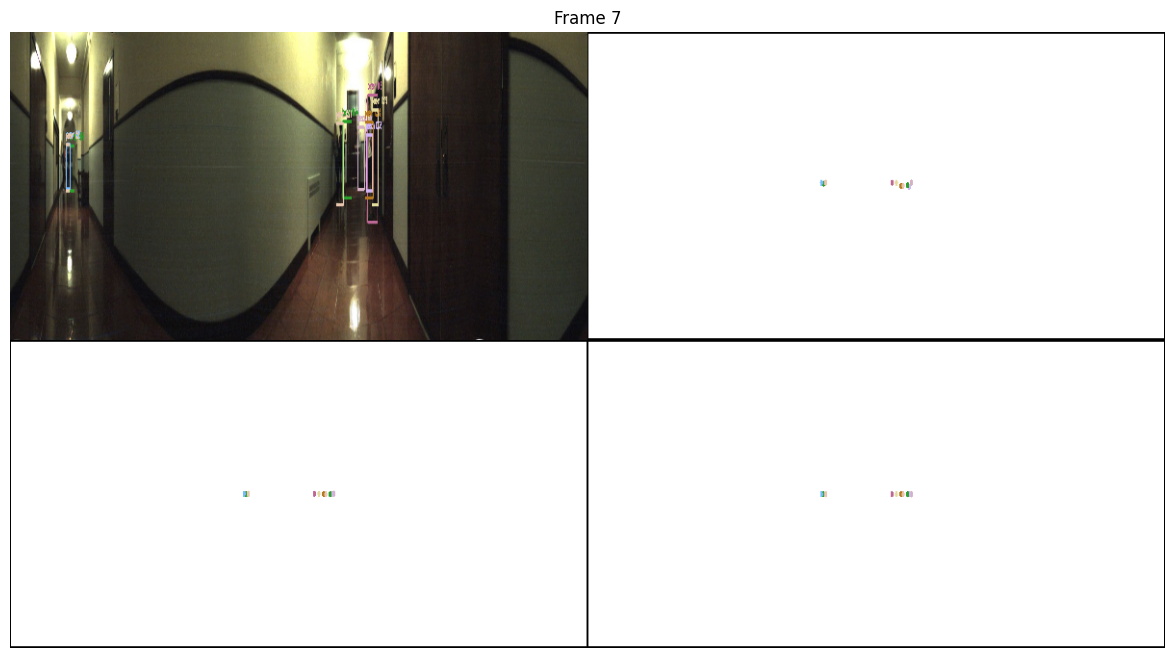

JRDB_gold/videos_frames/cubberly-auditorium-2019-04-22_1_00051/00009.jpeg
363
2361


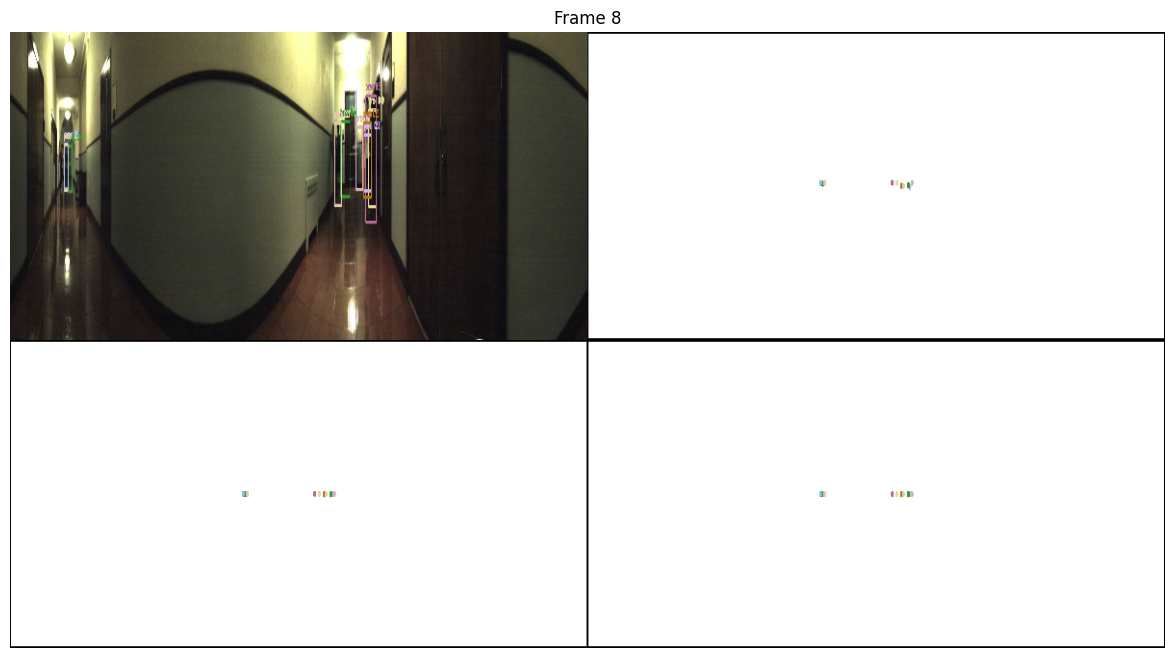

JRDB_gold/videos_frames/cubberly-auditorium-2019-04-22_1_00051/00010.jpeg
348
2347


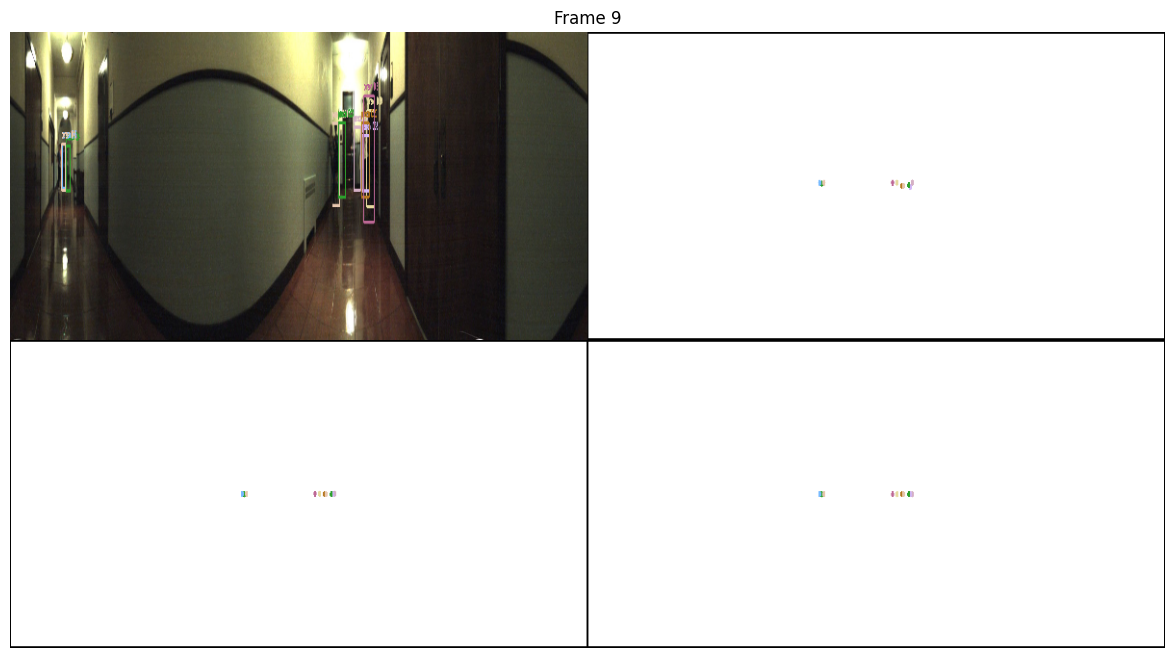

JRDB_gold/videos_frames/cubberly-auditorium-2019-04-22_1_00051/00011.jpeg
331
2333


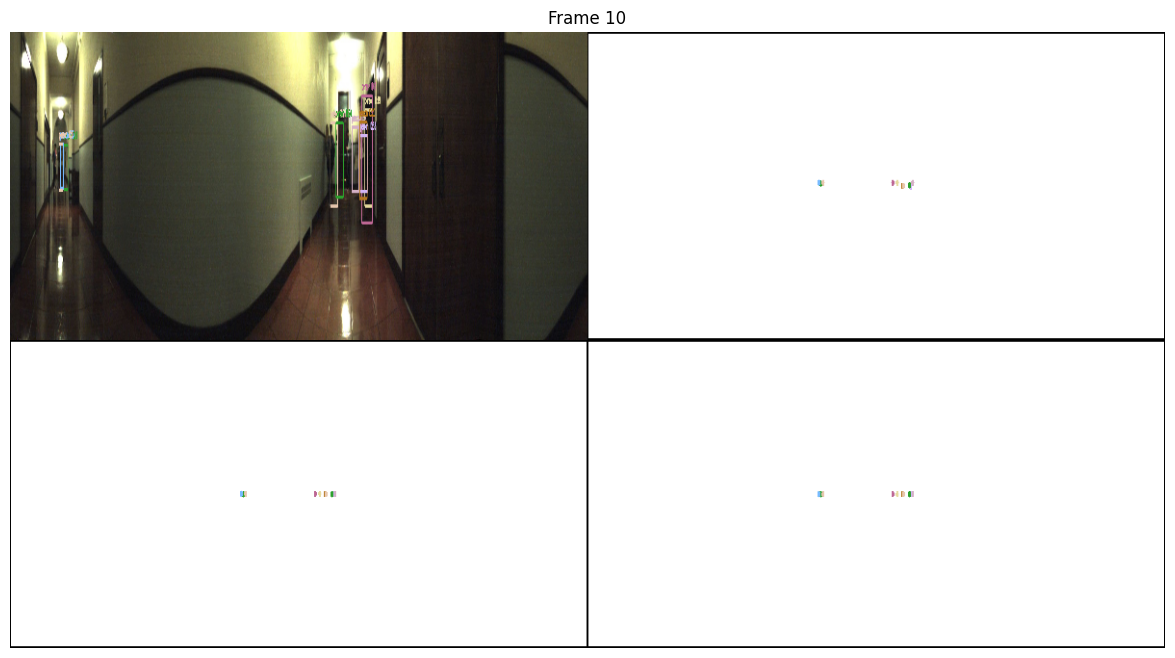

JRDB_gold/videos_frames/cubberly-auditorium-2019-04-22_1_00051/00012.jpeg
309
2315


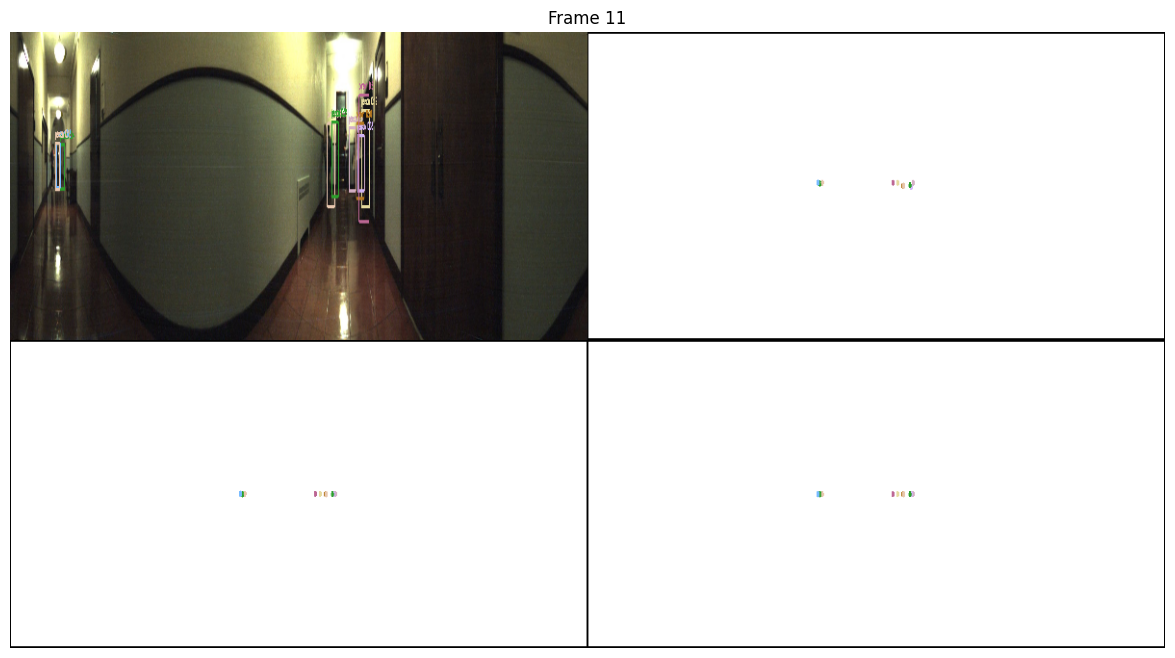

JRDB_gold/videos_frames/cubberly-auditorium-2019-04-22_1_00051/00013.jpeg
287
2297


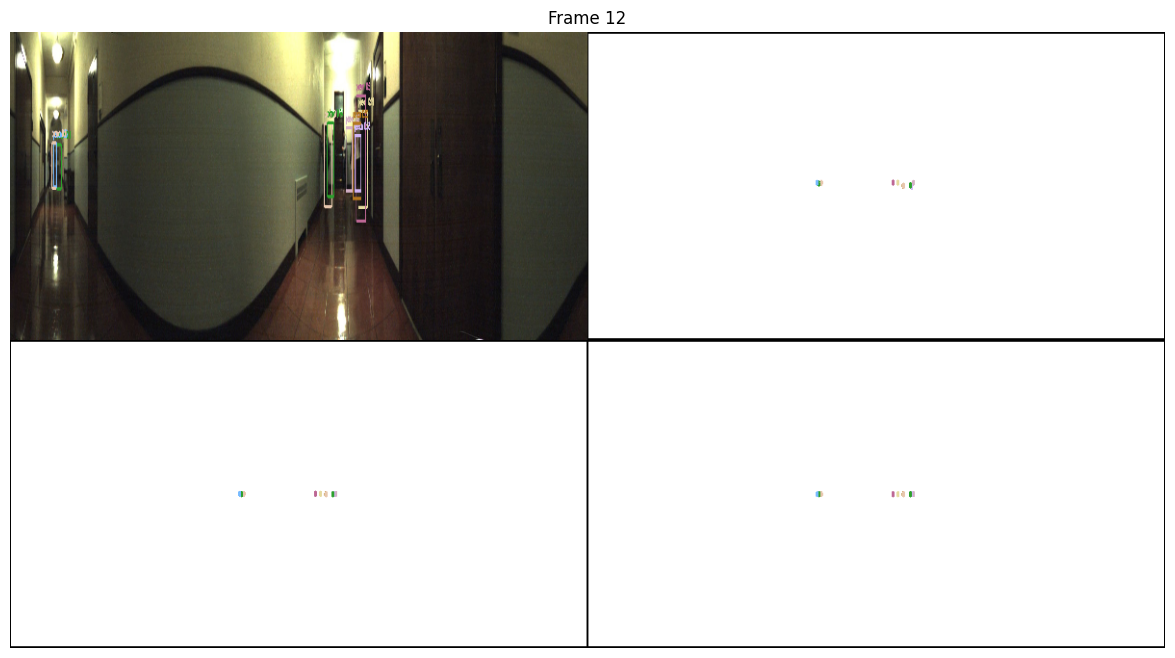

JRDB_gold/videos_frames/cubberly-auditorium-2019-04-22_1_00051/00014.jpeg
272
2283


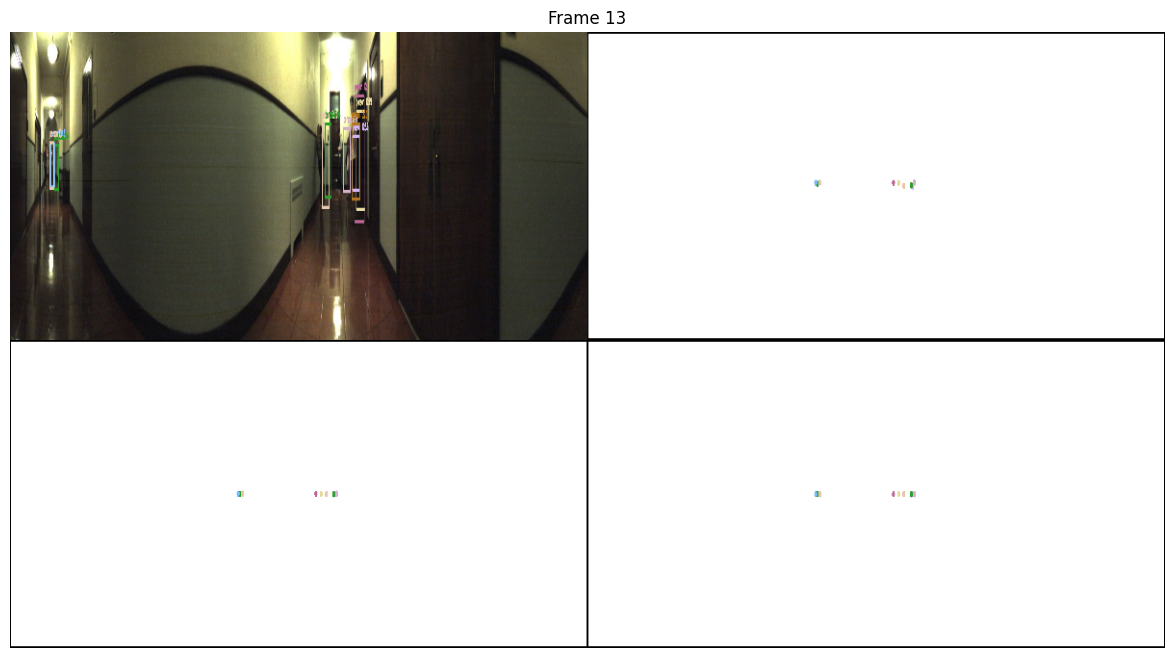

JRDB_gold/videos_frames/cubberly-auditorium-2019-04-22_1_00051/00015.jpeg
250
2265


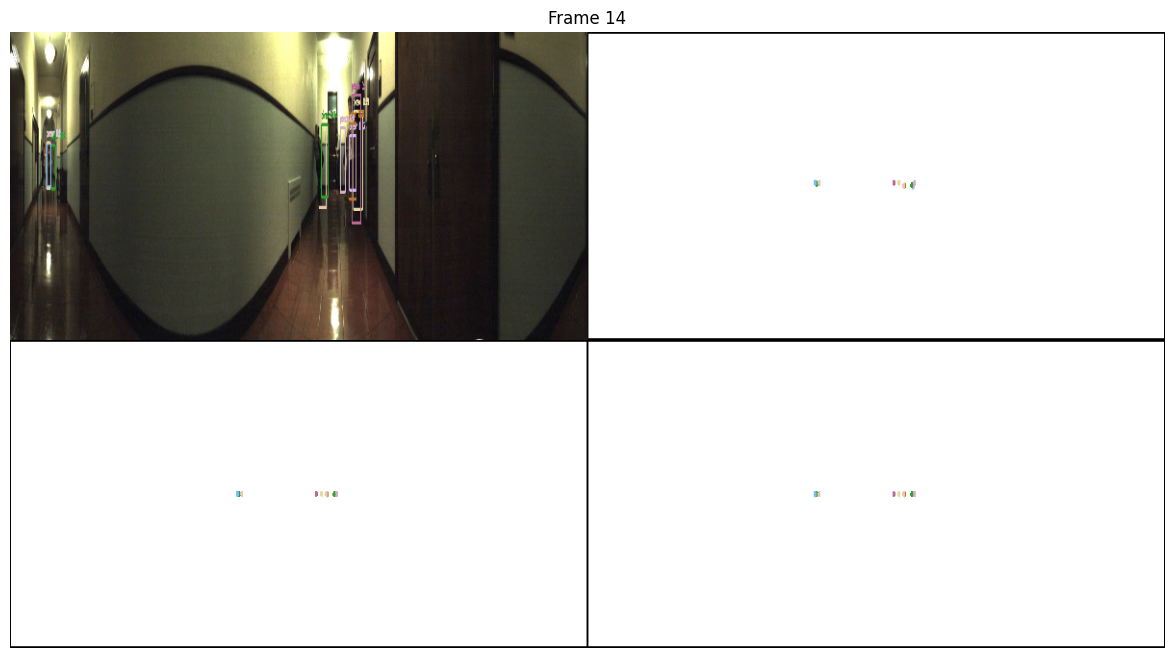

In [3]:
import numpy as np
import cv2
import networkx as nx
import math
import matplotlib.pyplot as plt
import torch
import json
import os
import glob

from PIL import Image
from transformers import pipeline
from our_utils import *

#video_name = 'bulk_process_1/Bilbao_Spain - Bilbao Spain walking tour [Bilbao Spain walking tour] - [z6-M9g6ayLE]'


dataset = 'JRDB_gold'
video_name = dataset+'/jsons_gold'


#video_name = 'BLENDER/jsons_step5'
#video_name = 'SEKAI_OURS/jsons_step5'

#print(video_name)

pattern = glob.escape(video_name) + "/*.json"
file = glob.glob(pattern)
file.sort()
file = file[51]
print(file)

#print(file)

with open(f"{file}", "r") as fp:
    data = json.load(fp)
    
cmap = plt.get_cmap("tab20")
colormap = plt.cm.get_cmap("tab20", 20)

N = 20
colors = [cmap(i) for i in range(N)]
palette = (np.array(colors)[:, :3] * 255).astype(np.uint8)

hash_table = {}

device = 'cuda' if torch.cuda.is_available() else 'cpu'

#video_path = 'BLENDER/videos_frames/'+file.split('/')[-1][:-5] # UPDATED
video_path = dataset+'/videos_frames/'+file.split('/')[-1][:-5] # UPDATED

#print(video_path)

files = glob.glob(video_path+'/*')

files.sort()
#print(files)
toProcess = data['frames']

for ind, frame_data in enumerate(toProcess):
    
    frame_id = frame_data['frame_id']
    detections = frame_data['detections']

    print(files[ind])
    image = cv2.imread(files[ind])    
    frame = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    black_size = 5
    coord1 = np.zeros((1000,image.shape[1],3),dtype=np.uint8)+255
    coord1[0:black_size, :] = 0
    coord1[:, 0:black_size] = 0
    coord1[-black_size:, :] = 0
    coord1[:, -black_size:] = 0
    
    coord2 = np.zeros((1000,image.shape[1],3),dtype=np.uint8)+255
    coord2[0:black_size, :] = 0
    coord2[:, 0:black_size] = 0
    coord2[-black_size:, :] = 0
    coord2[:, -black_size:] = 0
    
    coord3 = np.zeros((1000,image.shape[1],3),dtype=np.uint8)+255
    coord3[0:black_size, :] = 0
    coord3[:, 0:black_size] = 0
    coord3[-black_size:, :] = 0
    coord3[:, -black_size:] = 0

    a, b   = 1000000, 0
    min_x1, max_x1 = 1000000, 0
    min_x2, max_x2 = 1000000, 0
    min_x3, max_x3 = 1000000, 0
    
    for int_id, det in enumerate(detections):
        
        x1, y1, x2, y2 = map(int, det['bbox'])
        o1_mid = ((x1+x2)//2, (y1+y2)//2) 
        a = min(a, max(0,o1_mid[0]))
        b = max(b, o1_mid[0])
    
        X1, Y1, Z1 = det['3D'] #naive_3D_60FOV
        X2, Y2, Z2 = det['3D'] #detany_3D
        X3, Y3, Z3 = det['3D'] #unidepth_3D
        
        
        #X1, Y1, Z1 = det['naive_3D_60FOV']
        #X2, Y2, Z2 = det['detany_3D']
        #X3, Y3, Z3 = det['unidepth_3D']

        min_x1 = min((int(image.shape[1]//2)+int(X1)),min_x1)
        min_x2 = min((int(image.shape[1]//2)+int(X2)),min_x2)
        min_x3 = min((int(image.shape[1]//2)+int(X3)),min_x3)

        max_x1 = max((int(image.shape[1]//2)+int(X1)),max_x1)
        max_x2 = max((int(image.shape[1]//2)+int(X2)),max_x2)
        max_x3 = max((int(image.shape[1]//2)+int(X3)),max_x3)

    print(a)
    print(b)
    for int_id, det in enumerate(detections):
        
        x1, y1, x2, y2 = map(int, det['bbox'])
        track_id   = int(det['track_id'])
        class_name = 'person'
        label = f"{class_name} ID:{track_id}"
        rgb_tuple = (int(palette[track_id%20][0]),int(palette[track_id%20][1]),int(palette[track_id%20][2]))

        o1_mid = ((x1+x2)//2, (y1+y2)//2) 
        
        X1, Y1, Z1 = det['3D'] #naive_3D_60FOV
        X2, Y2, Z2 = det['3D'] #detany_3D
        X3, Y3, Z3 = det['3D'] #unidepth_3D

        #X1, Y1, Z1 = det['naive_3D_60FOV']
        #X2, Y2, Z2 = det['detany_3D']
        #X3, Y3, Z3 = det['unidepth_3D']

        X1*=30
        X2*=30
        X3*=30
        X1, X2, X3 = (int(image.shape[1]//2)+int(X1)), (int(image.shape[1]//2)+int(X2)), (int(image.shape[1]//2)+int(X3))
        
        h1, w1 = coord1.shape[:2]
        h2, w2 = coord2.shape[:2]
        h3, w3 = coord3.shape[:2]

        #nX1 = ((X1 - min_x1) / (max_x1 - min_x1+1e-5) ) * (b - a) + a
        #nX2 = ((X2 - min_x2) / (max_x2 - min_x2+1e-5) ) * (b - a) + a
        #nX3 = ((X3 - min_x3) / (max_x3 - min_x3+1e-5) ) * (b - a) + a

        nX1 = X1
        nX2 = X2
        nX3 = X3
        
        center1 = (int(nX1), 1000-(500+int(Z1*100))) # updated
        center2 = (int(nX2), 1000-(500+int(Z2*10))) # updated
        center3 = (int(nX3), 1000-(500+int(Z3*5))) # updated
        
        direction = det['direction']
        offset = 25
        plot_coord(coord1, center1, direction, offset, rgb_tuple)
        plot_coord(coord2, center2, direction, offset, rgb_tuple)
        plot_coord(coord3, center3, direction, offset, rgb_tuple)
        
        if class_name == 'person':
            draw_tracking(frame=image, bbox = det['bbox'], label=label, color=rgb_tuple)   
        
        
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    coord1 = cv2.cvtColor(coord1, cv2.COLOR_BGR2RGB)
    coord2 = cv2.cvtColor(coord2, cv2.COLOR_BGR2RGB)
    coord3 = cv2.cvtColor(coord3, cv2.COLOR_BGR2RGB)

    cv2.imwrite(f'boxes/{ind}.png',cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    
    combined_frame1 = np.hstack( [cv2.resize(image, (600, 320)), cv2.resize(coord1, (600, 320))])    
    combined_frame2 = np.hstack([cv2.resize(coord2, (600, 320)), cv2.resize(coord3, (600, 320))])
    combined_frame = np.vstack([combined_frame1, combined_frame2])
    
    #cv2.imwrite(f'{ind}.png',cv2.cvtColor(combined_frame, cv2.COLOR_BGR2RGB))
    plt.figure(figsize=(36, 8))
    plt.imshow(combined_frame)
    plt.axis("off")
    plt.title(f"Frame {ind}")
    plt.show()

